# 03 · Modelo Tabular (baseline)

**Objetivo:** Establecer un modelo baseline usando únicamente los metadatos clínicos (edad, sexo, localización) sin información visual.

**Datos de entrada:** `../data/raw/HAM10000_metadata.csv`

**Resultado esperado:** Modelo guardado en `../models/tabular_model.h5` con ~69% de accuracy en test.

**Arquitectura:** Red densa (Sequential) — 3 capas Dense con Dropout.

## Carga de datos y preprocesado

El preprocesado se realiza íntegramente en este notebook para que sea ejecutable de forma independiente. Las decisiones de diseño están documentadas en `02_data_preparation.ipynb`.

Train set: (8012, 17) (8012, 7)
Test set: (2003, 17) (2003, 7)
Clases: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


C:\Users\rammu\AppData\Local\Temp\ipykernel_22780\373640937.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata['age'].fillna(metadata['age'].median(), inplace=True)
c:\Users\rammu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,463 (13.53 KB)

 Trainable params: 3,463 (13.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6355 - loss: 1.2249 - val_accuracy: 0.6881 - val_loss: 0.9490
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6823 - loss: 1.0070 - val_accuracy: 0.6987 - val_loss: 0.9173
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6886 - loss: 0.9887 - val_accuracy: 0.7006 - val_loss: 0.9014
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6918 - loss: 0.9702 - val_accuracy: 0.7043 - val_loss: 0.8946
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6904 - loss: 0.9683 - val_accuracy: 0.7024 - val_loss: 0.8946
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6943 - loss: 0.9579 - val_accuracy: 0.7012 - val_loss: 0.8891
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6934 - loss: 0.9558 - val_accuracy: 0.7043 - val_loss: 0.8846
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6968 - loss: 0.9486 - val_accuracy: 0.

Test accuracy: 0.6985


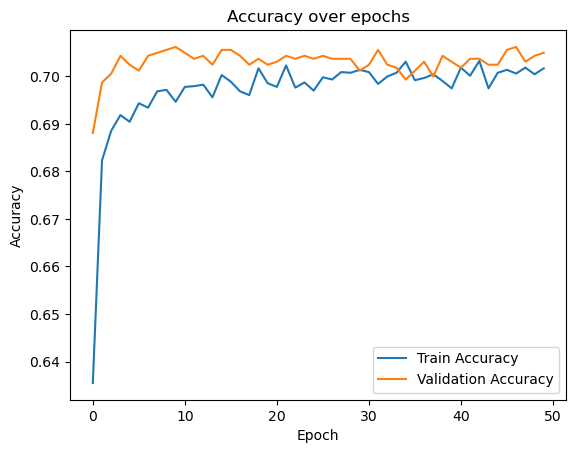

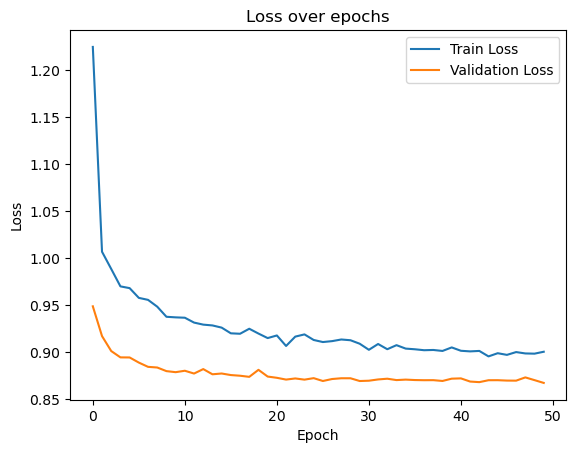

In [35]:
#Dado que vamos a hacer un modelo de clasificación sólo con datos tabulares, no queremos realizar en esta celda
#el preprocesamiento de las imágenes, así que a continuación está el código modificado para incluir sólo los datos tabulares
import os
import glob
import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Cargamos metadata
metadata = pd.read_csv(r"../data/raw/HAM10000_metadata.csv")
# Imputar nulos en 'age' 
metadata['age'].fillna(metadata['age'].median(), inplace=True)
metadata['age'] = metadata['age'].round().astype(int)
X = pd.get_dummies(metadata[['age',
    'sex', 'localization']], drop_first=True)
scaler = StandardScaler()
X['age'] = scaler.fit_transform(X[['age']])

# Codificar labels
y = metadata['dx']  # columna con las etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_onehot = to_categorical(y_encoded)

# Dividir en train/test 

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)
print("Clases:", label_encoder.classes_)
# Ahora X_train y X_test contienen sólo los datos tabulares preprocesados
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(7, activation='softmax')
])
# Compilar 
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.summary()
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')
# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

# Evaluación
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
#Graficamos los resultados de accuracy y loss
import matplotlib.pyplot as plt
#guardamos el modelo 
model.save('../models/tabular_model.h5')
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Pérdida
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Conclusiones del modelo tabular

Vemos que este modelo es muy limitado, ya que su precisión es aproximadamente de 0.69%. Esto es de esperar, ya que utiliza sólo metadatos de la lesión (la localización de la lesión, edad del paciente y su sexo), no la imagen real. Sin embargo, podría ser un buen punto de entrada para plantear un modelo Early o Late fusion donde utilicemos estos datos con un peso menor para ayudar a nuestras redes a entender mejor los datos de las imágenes. Además, nos sirve para comparar con los modelos basados sólo en imágenes y observar su efectividad
Además, como podemos ver en los gráficos, a partir de la epoch 10 conseguimos una efectividad bastante estable, por lo que probablemente limitar las epoch a 10 habría sido un buen movimiento (no lo hacemos porque al ser sólo metadatos, nuestras cpus y gpus ) hacen este trabajo con relativa facilidad y no nos supone mucho más tiempo)